In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
df = pd.read_csv("/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv")
print("Shape:", df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [2]:
import pydicom
import cv2
from tqdm import tqdm

image_id = df["image_id"].unique()
np.random.seed(42)
select_ids=np.random.choice(image_id,5000,replace=False)
output_dir = "/kaggle/working/images3000"
os.makedirs(output_dir, exist_ok=True)


input_dir = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

for img_id in tqdm(select_ids):

    
    dicom_path = os.path.join(input_dir, f"{img_id}.dicom")
    
    # Read DICOM
    ds = pydicom.dcmread(dicom_path)
    
    # Extract pixel data
    image = ds.pixel_array.astype(np.float32)
    
    # Normalize
    image -= image.min()
    if image.max() != 0:
        image /= image.max() 
    image *= 255.0
    
    # Convert to uint8
    image = image.astype(np.uint8)
    
    # Save as PNG
    save_path = os.path.join(output_dir, f"{img_id}.png") 
    cv2.imwrite(save_path, image)



100%|██████████| 5000/5000 [1:32:42<00:00,  1.11s/it]


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
import albumentations as A

# -----------------------------
# Config
# -----------------------------
input_dir = "/kaggle/working/images3000"
output_dir = "/kaggle/working/images3000_processed"
target_size = 224

os.makedirs(output_dir, exist_ok=True)

image_files = os.listdir(input_dir)
if len(image_files) == 0:
    raise ValueError("No images found in input_dir!")

# -----------------------------
# Augmentation Pipeline
# -----------------------------
augment = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),
    A.Affine(
        scale=(0.98, 1.02),
        translate_percent=(0.02, 0.02),
        rotate=0,
        p=0.3
    ),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2)
])

# -----------------------------
# Preprocessing Function
# -----------------------------
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img_blur = cv2.GaussianBlur(img, (3, 3), 0.3)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_blur)

    _, thresh = cv2.threshold(img_clahe, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img_cropped = img_clahe[y:y+h, x:x+w]
    else:
        img_cropped = img_clahe

    img_resized = cv2.resize(
        img_cropped,
        (target_size, target_size),
        interpolation=cv2.INTER_AREA
    )

    augmented = augment(image=img_resized)
    img_aug = augmented["image"]

    return img_aug

# -----------------------------
# Process All Images
# -----------------------------
for file in tqdm(image_files):
    input_path = os.path.join(input_dir, file)
    output_path = os.path.join(output_dir, file)

    if os.path.exists(output_path):
        continue

    processed_img = preprocess_image(input_path)

    if processed_img is not None:
        cv2.imwrite(output_path, processed_img)

print("All images processed and saved.")

100%|██████████| 5000/5000 [20:14<00:00,  4.12it/s]

All images processed and saved.


In [4]:
import os
import pandas as pd
import cv2
import numpy as np
import shutil
from tqdm import tqdm

# -----------------------------
# PATHS
# -----------------------------
ORIGINAL_IMAGE_DIR = "/kaggle/working/images3000"
PROCESSED_IMAGE_DIR = "/kaggle/working/images3000_processed"
CSV_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
YOLO_LABEL_DIR = "/kaggle/working/yolo_labels"

TARGET_SIZE = 224

# Reset folders
if os.path.exists(PROCESSED_IMAGE_DIR):
    shutil.rmtree(PROCESSED_IMAGE_DIR)
if os.path.exists(YOLO_LABEL_DIR):
    shutil.rmtree(YOLO_LABEL_DIR)

os.makedirs(PROCESSED_IMAGE_DIR, exist_ok=True)
os.makedirs(YOLO_LABEL_DIR, exist_ok=True)

# -----------------------------
# LOAD CSV
# -----------------------------
df = pd.read_csv(CSV_PATH)
available_images = set(os.listdir(ORIGINAL_IMAGE_DIR))

# -----------------------------
# PROCESS EACH IMAGE
# -----------------------------
for image_id in tqdm(df['image_id'].unique()):

    image_name = image_id + ".png"

    if image_name not in available_images:
        continue

    img_path = os.path.join(ORIGINAL_IMAGE_DIR, image_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    orig_h, orig_w = img.shape[:2]

    # ---- PREPROCESSING ----
    img_blur = cv2.GaussianBlur(img, (3, 3), 0.3)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_blur)

    # ---- CROP ----
    _, thresh = cv2.threshold(img_clahe, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        x_crop, y_crop, w_crop, h_crop = cv2.boundingRect(coords)
        img_cropped = img_clahe[y_crop:y_crop+h_crop, x_crop:x_crop+w_crop]
    else:
        x_crop, y_crop = 0, 0
        h_crop, w_crop = img_clahe.shape
        img_cropped = img_clahe

    # ---- RESIZE ----
    img_resized = cv2.resize(
        img_cropped,
        (TARGET_SIZE, TARGET_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # Save processed image
    cv2.imwrite(os.path.join(PROCESSED_IMAGE_DIR, image_name), img_resized)

    # -----------------------------
    # ADJUST BOUNDING BOXES
    # -----------------------------
    image_data = df[df['image_id'] == image_id]
    yolo_lines = []

    for _, row in image_data.iterrows():

        class_id = int(row['class_id'])

        if class_id == 14:
            continue

        if pd.isna(row['x_min']) or pd.isna(row['y_min']) \
           or pd.isna(row['x_max']) or pd.isna(row['y_max']):
            continue

        x_min = row['x_min']
        y_min = row['y_min']
        x_max = row['x_max']
        y_max = row['y_max']

        # ---- SHIFT AFTER CROP ----
        x_min -= x_crop
        x_max -= x_crop
        y_min -= y_crop
        y_max -= y_crop

        # Clip if box partially outside crop
        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(w_crop, x_max)
        y_max = min(h_crop, y_max)

        if x_max <= x_min or y_max <= y_min:
            continue

        # ---- SCALE AFTER RESIZE ----
        scale_x = TARGET_SIZE / w_crop
        scale_y = TARGET_SIZE / h_crop

        x_min *= scale_x
        x_max *= scale_x
        y_min *= scale_y
        y_max *= scale_y

        # ---- CONVERT TO YOLO ----
        xc = ((x_min + x_max) / 2) / TARGET_SIZE
        yc = ((y_min + y_max) / 2) / TARGET_SIZE
        bw = (x_max - x_min) / TARGET_SIZE
        bh = (y_max - y_min) / TARGET_SIZE

        yolo_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    # Save label file
    label_path = os.path.join(YOLO_LABEL_DIR, image_name.replace(".png", ".txt"))
    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

print("✅ Processed images + Corrected YOLO labels created.")

100%|██████████| 15000/15000 [22:29<00:00, 11.11it/s]

✅ Processed images + Corrected YOLO labels created.


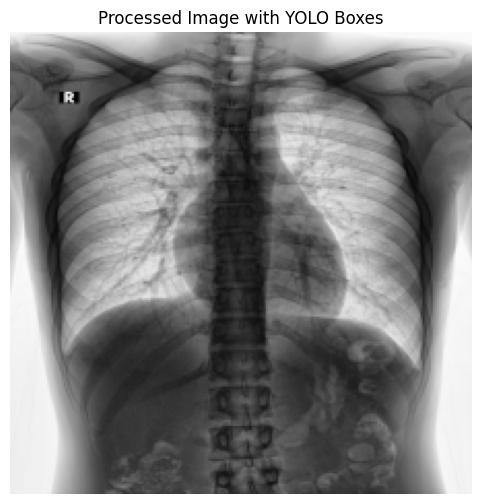

In [5]:

import random
import matplotlib.pyplot as plt

sample_image = random.choice(os.listdir(PROCESSED_IMAGE_DIR))

img_path = os.path.join(PROCESSED_IMAGE_DIR, sample_image)
label_path = os.path.join(YOLO_LABEL_DIR, sample_image.replace(".png", ".txt"))

img = cv2.imread(img_path)
h, w = img.shape[:2]

if os.path.exists(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:])

        x_min = int((xc - bw/2) * w)
        y_min = int((yc - bh/2) * h)
        x_max = int((xc + bw/2) * w)
        y_max = int((yc + bh/2) * h)

        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0,255,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Processed Image with YOLO Boxes")
plt.show()

In [6]:
augment = A.Compose(
    [
        A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=0.5
        ),
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.02, 0.02),
            rotate=(-5, 5),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3
    )
)

In [7]:
import os
import random
import shutil



IMAGE_DIR = "/kaggle/working/images3000_processed"  # use correct folder
LABEL_DIR = "/kaggle/working/yolo_labels"

BASE_DIR = "/kaggle/working/yolo_dataset"

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
TRAIN_LABEL_DIR = os.path.join(BASE_DIR, "train/labels")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test/images")
TEST_LABEL_DIR = os.path.join(BASE_DIR, "test/labels")


if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for folder in [TRAIN_IMG_DIR, TRAIN_LABEL_DIR, TEST_IMG_DIR, TEST_LABEL_DIR]:
    os.makedirs(folder, exist_ok=True)


images = []

for label_file in os.listdir(LABEL_DIR):
    if label_file.endswith(".txt"):
        image_name = label_file.replace(".txt", ".png")
        if os.path.exists(os.path.join(IMAGE_DIR, image_name)):
            images.append(image_name)

print(f"Total valid image-label pairs: {len(images)}")

if len(images) == 0:
    raise ValueError("No matching images found. Check paths.")



random.seed(42)
random.shuffle(images)


split_index = int(0.8 * len(images))

train_images = images[:split_index]
test_images = images[split_index:]


for image_name in train_images:
    shutil.copy(
        os.path.join(IMAGE_DIR, image_name),
        os.path.join(TRAIN_IMG_DIR, image_name)
    )
    shutil.copy(
        os.path.join(LABEL_DIR, image_name.replace(".png", ".txt")),
        os.path.join(TRAIN_LABEL_DIR, image_name.replace(".png", ".txt"))
    )

for image_name in test_images:
    shutil.copy(
        os.path.join(IMAGE_DIR, image_name),
        os.path.join(TEST_IMG_DIR, image_name)
    )
    shutil.copy(
        os.path.join(LABEL_DIR, image_name.replace(".png", ".txt")),
        os.path.join(TEST_LABEL_DIR, image_name.replace(".png", ".txt"))
    )



print("\n✅ Final Split Complete")
print(f"Train images: {len(train_images)} ({len(train_images)/len(images)*100:.2f}%)")
print(f"Test images:  {len(test_images)} ({len(test_images)/len(images)*100:.2f}%)")
print(f"Total images: {len(images)}")

Total valid image-label pairs: 5000

✅ Final Split Complete
Train images: 4000 (80.00%)
Test images:  1000 (20.00%)
Total images: 5000


In [8]:
import shutil

source_folder = "/kaggle/working/images3000_processed"
zip_path = "/kaggle/working/images3000_processed.zip"

shutil.make_archive(
    "/kaggle/working/images3000_processed",
    'zip',
    source_folder
)

print("Preprocessed images zipped successfully.")

Preprocessed images zipped successfully.
